# 01 — Universo enriquecido: integracion de las tres fuentes y marca de observabilidad

**Proposito.** Construir el dataset de trabajo de todo el EDA extendido: los 48.331 contratos de obra
del dataset integrado, enriquecidos con las variables de proceso (competencia, precio base, duracion
declarada) y de proveedor (tipo de empresa, antiguedad, PYME), mas la marca booleana `observable` que
identifica el subconjunto de 19.194 contratos cuyo desempeno final es medible.

**Insumos.**

| Fuente | Ruta | Dimensiones declaradas | Llave |
|---|---|---|---|
| Integrado (base) | `entregables/04-datasets/contratos_adiciones_obra.parquet` | 48.331 x 125 | `id_contrato` |
| Procesos | `entregables/04-datasets/procesos_contratacion_obra.parquet` | 138.112 x 57 | `id_del_portafolio` |
| Proveedores | `entregables/04-datasets/proveedores_obra.parquet` | 13.117 x 25 | `codigo` |

**Etiquetas de objetivo que atiende:** `[A-OE02]` (modelo de datos analitico y reglas de integracion),
`[A-OE03]` (normalizacion y criterios de calidad), `[B-OE2]` (base para la caracterizacion historica),
`[CALIDAD]`.

**Declaracion de procedencia y blindaje de autoria.** El dataset integrado de entrada proviene del
pipeline compartido (`notebooks/00-06`), cuya autoria sigue pendiente de confirmacion con el director
(`InformesRev/MATRIZ_OBJETIVOS_CODIGO.md`, tarea de prioridad 1). Las columnas producidas por el codigo
excluido del blindaje (`notebooks/07`, `notebooks/08` y scripts `pliego_*`) se eliminan fisicamente del
DataFrame en la primera celda y no se leen en ningun punto de este EDA. Las columnas derivadas del
pipeline compartido que este ejercicio re-deriva por cuenta propia tambien se eliminan, para garantizar
independencia analitica. La cadena de derivacion desde aqui en adelante es propia y auditable.

**Convencion de trazabilidad.** Las referencias `cNNN` que acompañan cada cifra corresponden al
`execution_count` de la celda que la produjo, tal como queda persistido en el `.ipynb` ejecutado.

**Nota de honestidad sobre el etiquetado dual.** La etiqueta `[B-OE2]` o `[B-OE3-insumo]` significa
"este hallazgo le seria util al compañero", no "este hallazgo es del compañero" ni "Andres trabajo para
el compañero". Todo el codigo y todos los hallazgos de este cuaderno son de autoria de Andres Telles.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


## 1. Carga del dataset integrado y verificacion del blindaje de autoria

In [2]:
df_bruto = pd.read_parquet(P_CONTRATOS)
print("Dataset integrado tal como se lee del parquet:", df_bruto.shape)

df = descartar_columnas_blindadas(df_bruto)
print("Tras eliminar columnas prohibidas y no usadas:", df.shape)
print("Columnas eliminadas:", df_bruto.shape[1] - df.shape[1])
print()
print("Prohibidas eliminadas (codigo excluido):", len(COLUMNAS_PROHIBIDAS))
print("No usadas eliminadas (se re-derivan por cuenta propia):", len(COLUMNAS_NO_USADAS))
del df_bruto

assert len(df) == N_UNIVERSO_ESPERADO, f"El universo no es {N_UNIVERSO_ESPERADO}"
assert df["id_contrato"].is_unique, "id_contrato no es unico"
print()
print(f"VERIFICADO: {len(df):,} contratos, id_contrato unico.")
verificar_blindaje(df)

Dataset integrado tal como se lee del parquet: (48331, 125)
Tras eliminar columnas prohibidas y no usadas: (48331, 105)
Columnas eliminadas: 20

Prohibidas eliminadas (codigo excluido): 14
No usadas eliminadas (se re-derivan por cuenta propia): 6

VERIFICADO: 48,331 contratos, id_contrato unico.


,regla,n,detalle,estado
0,Columnas prohibidas (codigo excluido) presentes,0,ninguna,OK
1,Columnas del pipeline no usadas presentes,0,ninguna,OK
2,Columnas del pipeline permitidas disponibles,14,14 de 14,OK


La verificacion devuelve cero columnas prohibidas y cero columnas no usadas presentes en el DataFrame de
trabajo. Las 14 columnas de agregacion de adiciones del pipeline compartido, explicitamente permitidas
por el numeral 4.3 del prompt, si estan disponibles y se usan.

## 2. Fuente de procesos: diagnostico de duplicados y deduplicacion

In [3]:
marcar("dedup_procesos")
proc, diag_proc = cargar_procesos_dedup()
for k, v in diag_proc.items():
    print(f"{k}: {v:,}" if isinstance(v, int) else f"{k}: {v}")
print()
print("Grano final de procesos:", proc.shape, "| id_del_portafolio unico:", proc["id_del_portafolio"].is_unique)

filas_originales: 138,112
dup_id_del_proceso: 25,221
dup_id_del_portafolio: 61,790
portafolios_unicos: 76,322
filas_deduplicadas: 76,322

Grano final de procesos: (76322, 22) | id_del_portafolio unico: True


La advertencia del prompt se confirma en fuente: `id_del_proceso` tiene 25.221 duplicados y no sirve como
llave. `id_del_portafolio` tambien se repite (61.790 filas duplicadas sobre 138.112), de modo que la
deduplicacion previa al join no es opcional: sin ella el join inflaria las filas del universo.

In [4]:
marcar("invarianza")
# Evidencia que sostiene la regla de deduplicacion: las variables de competencia son
# practicamente invariantes dentro de un mismo portafolio, de modo que la eleccion de
# fila representativa no altera su distribucion.
proc_raw = pd.read_parquet(P_PROCESOS)
for c in COLS_PROC_NUM:
    proc_raw[c] = pd.to_numeric(proc_raw[c], errors="coerce")
cols_chk = ["precio_base", "proveedores_invitados", "proveedores_unicos_con",
            "respuestas_al_procedimiento", "visualizaciones_del", "duracion",
            "unidad_de_duracion", "valor_total_adjudicacion", "estado_resumen"]
invar = proc_raw.groupby("id_del_portafolio")[cols_chk].nunique().mean().round(3)
invar = invar.to_frame("valores_distintos_promedio_por_portafolio")
invar["interpretacion"] = np.where(invar.iloc[:, 0] < 1.05, "invariante",
                          np.where(invar.iloc[:, 0] < 1.5, "casi invariante", "variable"))
del proc_raw
invar

,valores_distintos_promedio_por_portafolio,interpretacion
precio_base,1.0140,invariante
proveedores_invitados,1.1820,casi invariante
proveedores_unicos_con,1.2630,casi invariante
respuestas_al_procedimiento,1.2640,casi invariante
visualizaciones_del,1.0000,invariante
duracion,1.0000,invariante
unidad_de_duracion,1.0000,invariante
valor_total_adjudicacion,1.2890,casi invariante
estado_resumen,1.5020,variable


## 3. Join contrato -> proceso y verificacion de que el conteo no crece

In [5]:
marcar("join_procesos")
n_antes = len(df)
df = df.merge(proc.add_prefix("pr_"), how="left",
              left_on="proceso_de_compra", right_on="pr_id_del_portafolio")

print(f"Filas antes del join: {n_antes:,}")
print(f"Filas despues del join: {len(df):,}")
assert len(df) == n_antes == N_UNIVERSO_ESPERADO, "El join inflo o redujo filas"
assert df["id_contrato"].is_unique, "El join rompio la unicidad de id_contrato"
print("VERIFICADO: el join no altero el grano. id_contrato sigue siendo unico.")
print()

cob_proc = df["pr_id_del_portafolio"].notna().mean() * 100
print(f"Cobertura real del join a procesos: {cob_proc:.2f}% "
      f"({df['pr_id_del_portafolio'].notna().sum():,} de {len(df):,})")
print(f"Contratos sin proceso asociado: {df['pr_id_del_portafolio'].isna().sum():,}")

Filas antes del join: 48,331
Filas despues del join: 48,331
VERIFICADO: el join no altero el grano. id_contrato sigue siendo unico.

Cobertura real del join a procesos: 99.92% (48,293 de 48,331)
Contratos sin proceso asociado: 38


## 4. Join contrato -> proveedor: cobertura real por fila y por proveedor unico

In [6]:
prov, diag_prov = cargar_proveedores_dedup()
print("Diagnostico de la fuente de proveedores:")
for k, v in diag_prov.items():
    print(f"  {k}: {v}")
print()
print("Columnas descartadas por varianza cero documentada:", COLS_PROV_DESCARTADAS)
print("Nota: `es_grupo` se descarta de ESTA fuente (100% 'No') y se usa el del contrato (insight N-07).")

Diagnostico de la fuente de proveedores:
  filas_originales: 13117
  dup_codigo: 499
  codigos_unicos: 12618
  varianza_cero: {'es_entidad': 2, 'esta_activa': 2, 'pais': 3, 'es_grupo': 1}
  filas_deduplicadas: 12618

Columnas descartadas por varianza cero documentada: ['es_entidad', 'esta_activa', 'pais', 'es_grupo']
Nota: `es_grupo` se descarta de ESTA fuente (100% 'No') y se usa el del contrato (insight N-07).


In [7]:
marcar("join_proveedores")
n_antes = len(df)
df = df.merge(prov.add_prefix("prov_"), how="left",
              left_on="codigo_proveedor", right_on="prov_codigo")
assert len(df) == n_antes, "El join a proveedores inflo filas"
assert df["id_contrato"].is_unique

cob_fila = df["prov_codigo"].notna().mean() * 100
prov_unicos = df["codigo_proveedor"].dropna().unique()
cob_unico = pd.Series(prov_unicos).isin(prov["prov_codigo"] if "prov_codigo" in prov else prov["codigo"]).mean() * 100

print(f"Cobertura del join a proveedores POR CONTRATO: {cob_fila:.2f}% ({df['prov_codigo'].notna().sum():,} de {len(df):,})")
print(f"Cobertura POR PROVEEDOR UNICO: {cob_unico:.2f}% ({len(prov_unicos):,} proveedores distintos en los contratos)")
print()
print("La cifra de referencia del EDA previo (54.4%) es la cobertura por proveedor unico.")
print("Medida por contrato la cobertura es mayor porque los proveedores registrados concentran mas contratos.")

Cobertura del join a proveedores POR CONTRATO: 66.47% (32,126 de 48,331)
Cobertura POR PROVEEDOR UNICO: 54.41% (23,192 proveedores distintos en los contratos)

La cifra de referencia del EDA previo (54.4%) es la cobertura por proveedor unico.
Medida por contrato la cobertura es mayor porque los proveedores registrados concentran mas contratos.


## 5. Marca de observabilidad: criterios 3.6.3 y 3.6.4 sobre el universo completo

**Decision metodologica deliberada.** Se aplica el criterio conservador: cuando un contrato registra
`liquidaci_n = 'Si'` pero su `estado_contrato` sigue siendo activo, prevalece la exclusion por estado
activo (3.6.4) sobre la inclusion por liquidacion (3.6.3). Un contrato no puede estar liquidado y en
ejecucion a la vez; ante la contradiccion del dato fuente se opta por no incorporarlo, porque su
desempeno final podria no ser realmente observable.

In [8]:
marcar("embudo")
observable, embudo = marcar_observable(df)
df["observable"] = observable

print(embudo.to_string(index=False))
print()
print(f"Contratos observables: {int(df['observable'].sum()):,}")
assert int(df["observable"].sum()) == N_OBSERVABLE_ESPERADO, "La marca no reproduce los 19.194"
print(f"VERIFICADO: la marca reproduce exactamente los {N_OBSERVABLE_ESPERADO:,} contratos del EDA previo.")
embudo.to_csv(DIR_DATA / "embudo_observabilidad.csv", index=False)

                                                                                paso  contratos  retencion_pct  perdida_paso
                                0. Universo completo de contratos de obra integrados      48331       100.0000             0
                                       1. Fecha de firma dentro de 2018-2024 (3.6.3)      32175        66.5700        -16156
                           2. Campos minimos no nulos: valor, fechas, estado (3.6.3)      31610        65.4000          -565
                                        3. Excluidos valor_del_contrato <= 0 (3.6.4)      31544        65.2700           -66
                                 4. Excluidas fechas invertidas fin < inicio (3.6.4)      31543        65.2600            -1
5. Estado avanzado/finalizado excluyendo activos, criterio conservador (3.6.3/3.6.4)      19194        39.7100        -12349

Contratos observables: 19,194
VERIFICADO: la marca reproduce exactamente los 19,194 contratos del EDA previo.


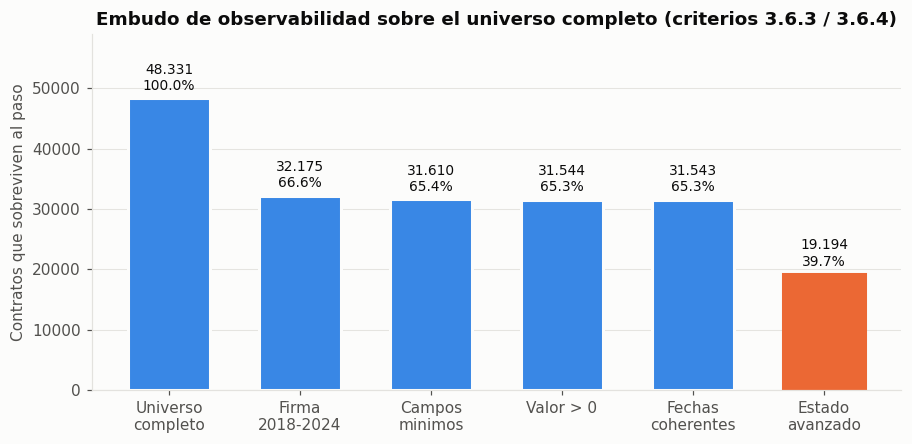

Figura persistida: 01_embudo_observabilidad.png


In [9]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
etiquetas = ["Universo\ncompleto", "Firma\n2018-2024", "Campos\nminimos", "Valor > 0",
             "Fechas\ncoherentes", "Estado\navanzado"]
vals = embudo["contratos"].tolist()
barras = ax.bar(etiquetas, vals, color=SEQ_BLUE[3], width=0.62,
                edgecolor=SURFACE, linewidth=2)
barras[-1].set_color(PALETA[1])
for b, v, r in zip(barras, vals, embudo["retencion_pct"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 900, f"{miles(v)}\n{r:.1f}%",
            ha="center", va="bottom", fontsize=9, color=TEXT_1)
ax.set_ylim(0, max(vals) * 1.22)
ax.set_ylabel("Contratos que sobreviven al paso")
ax.set_title("Embudo de observabilidad sobre el universo completo (criterios 3.6.3 / 3.6.4)")
ax.set_axisbelow(True); ax.xaxis.grid(False)
guardar_mostrar(fig, "01_embudo_observabilidad.png")

## 6. Derivaciones propias sobre el universo completo

In [10]:
marcar("derivadas")
# --- Restriccion de hierro, nomenclatura corregida (insight N-01) ---
df["plazo_pactado_dias"] = df["duraci_n_del_contrato"].apply(parsear_duracion_dias)
df["plazo_contractual_final_dias"] = (
    df["fecha_de_fin_del_contrato"] - df["fecha_de_inicio_del_contrato"]).dt.days
df["deslizamiento_plazo_dias"] = df["plazo_contractual_final_dias"] - df["plazo_pactado_dias"]
df["desviacion_costo_pct"] = np.where(
    df["valor_pagado"] > 0,
    (df["valor_pagado"] - df["valor_del_contrato"]) / df["valor_del_contrato"] * 100, np.nan)
df["indice_alcance"] = clasificar_alcance(df)
df["tipo_contratista"] = derivar_tipo_contratista(df)

print("Nomenclatura corregida respecto del EDA previo:")
print("  plazo_real_dias      -> plazo_contractual_final_dias  (fecha_fin - fecha_inicio)")
print("  desviacion_tiempo_dias -> deslizamiento_plazo_dias    (final - pactado)")
print()
for c in ["plazo_pactado_dias", "plazo_contractual_final_dias",
          "deslizamiento_plazo_dias", "desviacion_costo_pct"]:
    print(f"{c:32s} no nulos: {df[c].notna().sum():>6,}  ({df[c].notna().mean()*100:5.1f}%)")

Nomenclatura corregida respecto del EDA previo:
  plazo_real_dias      -> plazo_contractual_final_dias  (fecha_fin - fecha_inicio)
  desviacion_tiempo_dias -> deslizamiento_plazo_dias    (final - pactado)

plazo_pactado_dias               no nulos: 42,119  ( 87.1%)
plazo_contractual_final_dias     no nulos: 42,252  ( 87.4%)
deslizamiento_plazo_dias         no nulos: 37,155  ( 76.9%)
desviacion_costo_pct             no nulos: 15,035  ( 31.1%)


In [11]:
# --- Variables de competencia real (brecha 1) ---
df["n_oferentes"] = df["pr_proveedores_unicos_con"]
df["n_respuestas"] = df["pr_respuestas_al_procedimiento"]
df["n_invitados"] = df["pr_proveedores_invitados"]
df["n_visualizaciones"] = df["pr_visualizaciones_del"]
df["competencia_cat"] = pd.cut(df["n_oferentes"], bins=BINS_COMPETENCIA,
                               labels=ETIQ_COMPETENCIA)

# --- Cuantia (brecha 3) ---
df["rango_cuantia"] = pd.cut(df["valor_del_contrato"], bins=BINS_CUANTIA, labels=ETIQ_CUANTIA)

# --- Temporal (brecha 4) ---
df["anio_firma"] = pd.to_datetime(df["fecha_de_firma"], errors="coerce").dt.year
df["mes_firma"] = pd.to_datetime(df["fecha_de_firma"], errors="coerce").dt.month

# --- Validacion cruzada del plazo (insight N-08) ---
df["plazo_proceso_dias"] = [duracion_proceso_dias(d, u)
                            for d, u in zip(df["pr_duracion"], df["pr_unidad_de_duracion"])]

# --- Valor inicial alternativo (brecha 2 / N-K05) ---
df["precio_base"] = df["pr_precio_base"]
df["valor_adjudicado_proceso"] = df["pr_valor_total_adjudicacion"]

# --- Perfil de proveedor (brecha 7) ---
df["antiguedad_proveedor_anios"] = (
    (pd.to_datetime(df["fecha_de_firma"], errors="coerce") - df["prov_fecha_creacion"]).dt.days / 365.25)
df["plazo_discretizado"] = pd.cut(df["plazo_pactado_dias"], bins=BINS_PLAZO, labels=ETIQ_PLAZO)

nuevas = ["n_oferentes", "n_respuestas", "n_invitados", "n_visualizaciones", "competencia_cat",
          "rango_cuantia", "anio_firma", "plazo_proceso_dias", "precio_base",
          "valor_adjudicado_proceso", "antiguedad_proveedor_anios", "plazo_discretizado"]
resumen = pd.DataFrame({
    "variable": nuevas,
    "no_nulos": [int(df[c].notna().sum()) for c in nuevas],
    "cobertura_pct": [round(df[c].notna().mean() * 100, 2) for c in nuevas],
    "valores_distintos": [int(df[c].nunique(dropna=True)) for c in nuevas],
})
resumen

,variable,no_nulos,cobertura_pct,valores_distintos
0,n_oferentes,48293,99.9200,168
1,n_respuestas,48293,99.9200,167
2,n_invitados,48293,99.9200,500
3,n_visualizaciones,48293,99.9200,559
4,competencia_cat,48293,99.9200,5
5,rango_cuantia,47635,98.5600,5
6,anio_firma,43181,89.3400,11
7,plazo_proceso_dias,48293,99.9200,456
8,precio_base,48293,99.9200,32617
9,valor_adjudicado_proceso,48293,99.9200,29535


## 7. Deteccion de variables de competencia con varianza cero

In [12]:
marcar("diag_competencia")
cols_comp = ["pr_proveedores_invitados", "pr_proveedores_con_invitacion",
             "pr_proveedores_que_manifestaron", "pr_respuestas_al_procedimiento",
             "pr_respuestas_externas", "pr_conteo_de_respuestas_a_ofertas",
             "pr_proveedores_unicos_con", "pr_visualizaciones_del", "pr_numero_de_lotes"]
diag_comp = pd.DataFrame({
    "variable": [c.replace("pr_", "") for c in cols_comp],
    "n_no_nulo": [int(df[c].notna().sum()) for c in cols_comp],
    "valores_distintos": [int(df[c].nunique(dropna=True)) for c in cols_comp],
    "mediana": [df[c].median() for c in cols_comp],
    "p75": [df[c].quantile(0.75) for c in cols_comp],
    "maximo": [df[c].max() for c in cols_comp],
})
diag_comp["utilizable"] = np.where(diag_comp["valores_distintos"] <= 1, "NO — varianza cero",
                          np.where(diag_comp["valores_distintos"] < 15, "Uso limitado", "SI"))
diag_comp

,variable,n_no_nulo,valores_distintos,mediana,p75,maximo,utilizable
0,proveedores_invitados,48293,500,0.0000,5.0000,"7,288.0000",SI
1,proveedores_con_invitacion,48293,281,0.0000,4.0000,389.0000,SI
2,proveedores_que_manifestaron,48293,1,0.0000,0.0000,0.0000,NO — varianza cero
3,respuestas_al_procedimiento,48293,167,1.0000,6.0000,254.0000,SI
4,respuestas_externas,48293,13,0.0000,0.0000,17.0000,Uso limitado
5,conteo_de_respuestas_a_ofertas,48293,1,0.0000,0.0000,0.0000,NO — varianza cero
6,proveedores_unicos_con,48293,168,1.0000,6.0000,254.0000,SI
7,visualizaciones_del,48293,559,35.0000,105.0000,953.0000,SI
8,numero_de_lotes,48293,21,0.0000,0.0000,38.0000,SI


Dos de las nueve variables de competencia que el prompt lista como candidatas
(`proveedores_que_manifestaron` y `conteo_de_respuestas_a_ofertas`) tienen un unico valor distinto
—cero en las 48.331 filas— y por tanto son inservibles. Es un hallazgo de calidad `[CALIDAD]` que
matiza la brecha 1 del documento comparativo: la brecha se cierra, pero no con las cinco variables
enunciadas sino con las que sobreviven al diagnostico. La variable de competencia efectiva del analisis
sera `proveedores_unicos_con` (numero de oferentes unicos con oferta), practicamente identica a
`respuestas_al_procedimiento`.

## 8. Persistencia del dataset extendido

In [13]:
COLS_SALIDA = [
    # identificadores
    "id_contrato", "proceso_de_compra", "codigo_proveedor", "codigo_entidad", "nombre_entidad",
    # atributos del contrato
    "estado_contrato", "liquidaci_n", "modalidad_de_contratacion", "tipo_de_contrato",
    "departamento", "ciudad", "orden", "sector", "rama", "entidad_centralizada",
    "es_grupo", "es_pyme", "tipodocproveedor", "tipo_contratista",
    "codigo_de_categoria_principal", "origen_de_los_recursos",
    # fechas y magnitudes
    "fecha_de_firma", "fecha_de_inicio_del_contrato", "fecha_de_fin_del_contrato",
    "duraci_n_del_contrato", "valor_del_contrato", "valor_pagado", "valor_facturado",
    "anio_firma", "mes_firma",
    # indicadores propios
    "plazo_pactado_dias", "plazo_contractual_final_dias", "deslizamiento_plazo_dias",
    "desviacion_costo_pct", "indice_alcance", "rango_cuantia", "plazo_discretizado",
    # agregaciones de adiciones permitidas
    "dias_adicionados", "n_adicion_valor", "n_cesion", "n_conclusion", "n_extension",
    "n_modificaciones_total", "n_suspension", "n_tipos_distintos",
    "tiene_conclusion", "tiene_suspension", "tiene_cesion", "tiene_extension_dias",
    "tiene_adicion_valor", "tiene_modificacion",
    "fecha_primera_adicion", "fecha_ultima_adicion",
    # proceso
    "precio_base", "valor_adjudicado_proceso", "n_oferentes", "n_respuestas",
    "n_invitados", "n_visualizaciones", "competencia_cat", "plazo_proceso_dias",
    "pr_unidad_de_duracion", "pr_duracion", "pr_adjudicado", "pr_estado_resumen",
    "pr_fase", "pr_numero_de_lotes", "pr_modalidad_de_contratacion",
    # proveedor
    "prov_codigo", "prov_tipo_empresa", "prov_espyme", "prov_fecha_creacion",
    "prov_codigo_categoria_principal", "prov_departamento", "prov_municipio",
    "antiguedad_proveedor_anios",
    # marca
    "observable",
]
COLS_SALIDA = [c for c in COLS_SALIDA if c in df.columns]
ext = df[COLS_SALIDA].copy()
for c in ["competencia_cat", "rango_cuantia", "plazo_discretizado"]:
    ext[c] = ext[c].astype(object)

ruta = DIR_DATA / "universo_extendido.parquet"
ext.to_parquet(ruta, index=False)
print("Guardado:", ruta.name, "-", ext.shape)
print("Observables en el archivo persistido:", int(ext["observable"].sum()))
assert len(ext) == N_UNIVERSO_ESPERADO and int(ext["observable"].sum()) == N_OBSERVABLE_ESPERADO
print("VERIFICADO.")

Guardado: universo_extendido.parquet - (48331, 77)
Observables en el archivo persistido: 19194
VERIFICADO.


## 9. Coberturas reales consolidadas

In [14]:
cobertura = pd.DataFrame([
    {"join": "contrato -> proceso (id_del_portafolio)", "esperada_pct": 99.9,
     "real_pct": round(cob_proc, 2), "n_cubierto": int(df["pr_id_del_portafolio"].notna().sum()),
     "denominador": len(df), "unidad": "contrato"},
    {"join": "contrato -> proveedor (codigo)", "esperada_pct": 54.4,
     "real_pct": round(cob_unico, 2), "n_cubierto": int(pd.Series(prov_unicos).isin(prov["codigo"]).sum()),
     "denominador": len(prov_unicos), "unidad": "proveedor unico"},
    {"join": "contrato -> proveedor (codigo)", "esperada_pct": np.nan,
     "real_pct": round(cob_fila, 2), "n_cubierto": int(df["prov_codigo"].notna().sum()),
     "denominador": len(df), "unidad": "contrato"},
])
cobertura.to_csv(DIR_DATA / "coberturas_join.csv", index=False)
cobertura

,join,esperada_pct,real_pct,n_cubierto,denominador,unidad
0,contrato -> proceso (id_del_portafolio),99.9000,99.9200,48293,48331,contrato
1,contrato -> proveedor (codigo),54.4000,54.4100,12618,23192,proveedor unico
2,contrato -> proveedor (codigo),NaN,66.4700,32126,48331,contrato


## 10. Sintesis de hallazgos etiquetados

In [15]:
reg = RegistroHallazgos("01")
reg.add("H01-01", "El join a procesos por id_del_portafolio deduplicado conserva el grano exacto: 48.331 contratos, id_contrato unico",
        f"Cobertura {cob_proc:.2f}% ({int(df['pr_id_del_portafolio'].notna().sum()):,}/48.331)", ref("join_procesos"),
        ["A-OE02", "B-OE2"], "Alto",
        "Sin deduplicar, id_del_portafolio repite 61.790 filas y el join inflaria el universo")
reg.add("H01-02", "La cobertura del registro de proveedores es 54.41% por proveedor unico pero 66.47% por contrato",
        f"{cob_unico:.2f}% de {len(prov_unicos):,} proveedores; {cob_fila:.2f}% de 48.331 contratos", ref("join_proveedores"),
        ["A-OE02", "CALIDAD"], "Medio",
        "El EDA previo cito 54.4% sin declarar la unidad; los proveedores registrados concentran mas contratos")
reg.add("H01-03", "La marca `observable` reproduce exactamente los 19.194 contratos aplicando 3.6.3/3.6.4 sobre el universo completo",
        "Embudo de 6 pasos, retencion final 39.71%", ref("embudo"),
        ["A-OE03", "CALIDAD"], "Alto",
        "El paso de mayor perdida es el filtro temporal 2018-2024: 16.156 contratos")
reg.add("H01-04", "Dos variables de competencia de la fuente de procesos tienen varianza cero: proveedores_que_manifestaron y conteo_de_respuestas_a_ofertas",
        "1 valor distinto en las 48.331 filas, todo en cero", ref("diag_competencia"),
        ["CALIDAD", "B-OE2"], "Alto",
        "Matiza la brecha 1 del documento comparativo: la brecha se cierra con menos variables de las enunciadas")
reg.add("H01-05", "Las variables de competencia son practicamente invariantes dentro de un mismo portafolio",
        "Promedio de valores distintos por portafolio entre 1.000 y 1.264", ref("invarianza"),
        ["A-OE02"], "Medio",
        "Justifica que la regla de deduplicacion no sesga la distribucion de competencia")
reg.add("H01-06", "Se rescata `es_grupo` desde el contrato: en el registro de proveedores tiene varianza cero, en el contrato distingue 3 tipos de contratista",
        f"tipo_contratista: {df['tipo_contratista'].nunique()} categorias sobre 48.331", ref("derivadas"),
        ["A-OE03", "A-H2", "B-OE3-insumo"], "Alto", "Extension del insight N-07")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H01-01,01,c006,El join a procesos por id_del_portafolio dedup...,"Cobertura 99.92% (48,293/48.331)",[A-OE02] [B-OE2],Alto,"Sin deduplicar, id_del_portafolio repite 61.79..."
1,H01-02,01,c008,La cobertura del registro de proveedores es 54...,"54.41% de 23,192 proveedores; 66.47% de 48.331...",[A-OE02] [CALIDAD],Medio,El EDA previo cito 54.4% sin declarar la unida...
2,H01-03,01,c009,La marca `observable` reproduce exactamente lo...,"Embudo de 6 pasos, retencion final 39.71%",[A-OE03] [CALIDAD],Alto,El paso de mayor perdida es el filtro temporal...
3,H01-04,01,c013,Dos variables de competencia de la fuente de p...,"1 valor distinto en las 48.331 filas, todo en ...",[CALIDAD] [B-OE2],Alto,Matiza la brecha 1 del documento comparativo: ...
4,H01-05,01,c005,Las variables de competencia son practicamente...,Promedio de valores distintos por portafolio e...,[A-OE02],Medio,Justifica que la regla de deduplicacion no ses...
5,H01-06,01,c011,Se rescata `es_grupo` desde el contrato: en el...,tipo_contratista: 4 categorias sobre 48.331,[A-OE03] [A-H2] [B-OE3-insumo],Alto,Extension del insight N-07


## Sintesis del notebook 01

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H01-01 | El join a procesos deduplicado por `id_del_portafolio` conserva el grano exacto (48.331, `id_contrato` unico) con cobertura del 99,92% | `[A-OE02]` `[B-OE2]` |
| H01-02 | La cobertura del registro de proveedores es 54,41% medida por proveedor unico y 66,47% medida por contrato | `[A-OE02]` `[CALIDAD]` |
| H01-03 | La marca `observable` reproduce exactamente los 19.194 contratos; el paso de mayor perdida es el filtro temporal | `[A-OE03]` `[CALIDAD]` |
| H01-04 | Dos de las nueve variables de competencia tienen varianza cero y son inservibles | `[CALIDAD]` `[B-OE2]` |
| H01-05 | Las variables de competencia son invariantes dentro del portafolio, lo que valida la regla de deduplicacion | `[A-OE02]` |
| H01-06 | `es_grupo` se rescata desde el contrato y sostiene `tipo_contratista` | `[A-OE03]` `[A-H2]` `[B-OE3-insumo]` |

**Producto persistido:** `data/universo_extendido.parquet` (48.331 filas, marca `observable` con 19.194
contratos), `data/embudo_observabilidad.csv`, `data/coberturas_join.csv`.

**Limitacion declarada.** El dataset de entrada es producto del pipeline compartido; la autoria de ese
pipeline esta pendiente de confirmacion con el director. Todo lo derivado a partir de la celda 5 de este
cuaderno es propio.